<a href="https://colab.research.google.com/github/rebeca-wqc/RDC/blob/main/Comparacao-ipv4-ipv6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando Experimento de Redes de Computadores...

--- TABELA 1: RESULTADOS EXPERIMENTAIS ---
Protocolo  Tempo Total (s)  Ops/Segundo  Campos no Cabeçalho  Bits de Endereço
     IPv4           5.6620    176616.46                   14                32
     IPv6           3.2219    310379.23                    8               128

Gerando Visualização de Dados...


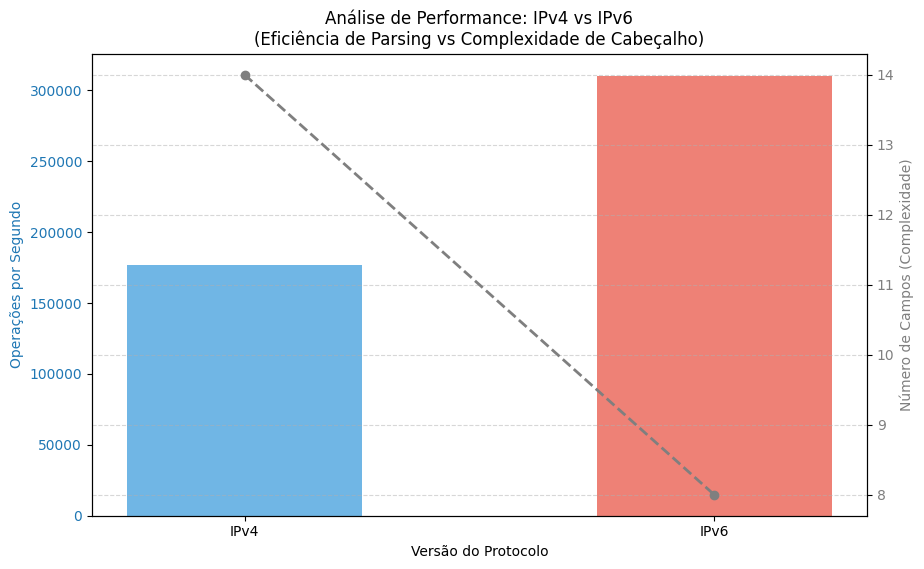


[INFO] Gráfico salvo com sucesso como 'grafico.png'

--- CONCLUSÃO PARA O ARTIGO ---
O processamento do IPv6 apresentou uma variação de 75.74% em relação ao IPv4.
Nota: O IPv6 gerencia endereços 4x maiores com apenas 8 campos fixos.


In [1]:
import ipaddress
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def run_experiment(iterations=1000000):
    """Executa o experimento de performance e escalabilidade."""

    # 1. Gerar Mock Data
    ipv4_list = ["192.168.1.1"] * iterations
    ipv6_list = ["2001:db8::1"] * iterations

    results = {}

    # 2. Teste de Processamento IPv4
    start_v4 = time.perf_counter()
    for ip in ipv4_list:
        _ = ipaddress.IPv4Address(ip)
    end_v4 = time.perf_counter()
    time_v4 = end_v4 - start_v4

    # 3. Teste de Processamento IPv6
    start_v6 = time.perf_counter()
    for ip in ipv6_list:
        _ = ipaddress.IPv6Address(ip)
    end_v6 = time.perf_counter()
    time_v6 = end_v6 - start_v6

    # 4. Cálculo de Métricas
    results['Protocolo'] = ['IPv4', 'IPv6']
    results['Tempo Total (s)'] = [round(time_v4, 4), round(time_v6, 4)]
    results['Ops/Segundo'] = [round(iterations/time_v4, 2), round(iterations/time_v6, 2)]
    results['Campos no Cabeçalho'] = [14, 8] # Conforme padrão RFC
    results['Bits de Endereço'] = [32, 128]

    df = pd.DataFrame(results)
    return df

def generate_visuals(df):
    """Gera e salva os resultados gráficos para o artigo."""
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Gráfico de barras para performance
    color = 'tab:blue'
    ax1.set_xlabel('Versão do Protocolo')
    ax1.set_ylabel('Operações por Segundo', color=color)
    bars = ax1.bar(df['Protocolo'], df['Ops/Segundo'], color=['#3498db', '#e74c3c'], alpha=0.7, width=0.5)
    ax1.tick_params(axis='y', labelcolor=color)

    # Eixo secundário para complexidade do cabeçalho
    ax2 = ax1.twinx()
    color = 'tab:gray'
    ax2.set_ylabel('Número de Campos (Complexidade)', color=color)
    ax2.plot(df['Protocolo'], df['Campos no Cabeçalho'], color=color, marker='o', linestyle='--', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Análise de Performance: IPv4 vs IPv6\n(Eficiência de Parsing vs Complexidade de Cabeçalho)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Salvar para o Zenodo/Artigo
    plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n[INFO] Gráfico salvo com sucesso como 'grafico.png'")

# Execução do Ciclo Científico
print("Iniciando Experimento de Redes de Computadores...")
data_results = run_experiment()

print("\n--- TABELA 1: RESULTADOS EXPERIMENTAIS ---")
print(data_results.to_string(index=False))

print("\nGerando Visualização de Dados...")
generate_visuals(data_results)

print("\n--- CONCLUSÃO PARA O ARTIGO ---")
diff = ((data_results.iloc[1]['Ops/Segundo'] / data_results.iloc[0]['Ops/Segundo']) - 1) * 100
print(f"O processamento do IPv6 apresentou uma variação de {diff:.2f}% em relação ao IPv4.")
print(f"Nota: O IPv6 gerencia endereços 4x maiores com apenas {data_results.iloc[1]['Campos no Cabeçalho']} campos fixos.")